In [1]:
#Environment Paths & Directory Setup
import logging
import sys
from pathlib import Path

# Setup Google Drive mount if running in Google Colab
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    has_colab = True
except Exception:
    has_colab = False

# Path Resolution
DEFAULT_COLAB_ROOT = Path("/content/drive/MyDrive/MPLADs")
ALT_COLAB_ROOT = Path("/content/drive/MYDrive/MPLADs")

if has_colab and DEFAULT_COLAB_ROOT.exists():
    PROJECT_ROOT = DEFAULT_COLAB_ROOT
elif has_colab and ALT_COLAB_ROOT.exists():
    PROJECT_ROOT = ALT_COLAB_ROOT
elif (Path.cwd() / "shared_preprocessing_artifacts").exists():
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd()

SHARED_ARTIFACT_DIR = PROJECT_ROOT / "shared_preprocessing_artifacts"
FEATURE1_ARTIFACT_DIR = PROJECT_ROOT / "feature1_artifacts"
FEATURE2_ARTIFACT_DIR = PROJECT_ROOT / "feature2_artifacts"
FEATURE3_ARTIFACT_DIR = PROJECT_ROOT / "feature3_artifacts"
OUTPUT_DIR = PROJECT_ROOT / "feature5_artifacts"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("mplads_feature5")

logger.info("Project Root: %s", PROJECT_ROOT)
logger.info("Shared Artifacts Dir: %s", SHARED_ARTIFACT_DIR)
logger.info("Feature 1 Artifacts Dir: %s", FEATURE1_ARTIFACT_DIR)
logger.info("Feature 2 Artifacts Dir: %s", FEATURE2_ARTIFACT_DIR)
logger.info("Feature 5 Output Dir: %s", OUTPUT_DIR)



Mounted at /content/drive


In [2]:
# Data Ingestion & Data Bus Resolution
import pandas as pd
import numpy as np

def read_artifact(dir_path: Path, name: str) -> pd.DataFrame:
    """Reads parquet artifact if available, falling back to CSV."""
    parquet_path = dir_path / f"{name}.parquet"
    csv_path = dir_path / f"{name}.csv"

    if parquet_path.exists():
        try:
            logger.info("Loading parquet: %s", parquet_path)
            return pd.read_parquet(parquet_path)
        except Exception as e:
            logger.warning("Failed loading parquet %s (%s). Falling back to CSV.", parquet_path, e)

    if csv_path.exists():
        logger.info("Loading CSV: %s", csv_path)
        return pd.read_csv(csv_path, low_memory=False)

    raise FileNotFoundError(f"Could not find {name}.parquet or {name}.csv in {dir_path}")

# Load Expenditure Fact Table
logger.info("--- Loading Expenditure Fact Table ---")
fact_expenditure = read_artifact(SHARED_ARTIFACT_DIR, "fact_expenditure")
logger.info("Loaded fact_expenditure shape: %s", fact_expenditure.shape)

# Resolve Work Fact Table from Data Bus (Handoff chain: F2 -> F1 -> F3 -> Shared)
fact_work = None
search_targets = [
    (SHARED_ARTIFACT_DIR, "fact_work_feature2"),
    (FEATURE2_ARTIFACT_DIR, "feature2_fact_work_cost_risk"),
    (SHARED_ARTIFACT_DIR, "fact_work_feature1"),
    (FEATURE1_ARTIFACT_DIR, "feature1_fact_work_disbursement_risk"),
    (FEATURE3_ARTIFACT_DIR, "feature3_fact_work_enriched"),
    (SHARED_ARTIFACT_DIR, "fact_work"),
]

for target_dir, target_name in search_targets:
    try:
        fact_work = read_artifact(target_dir, target_name)
        logger.info("Successfully loaded work data bus table from %s/%s. Shape: %s", target_dir.name, target_name, fact_work.shape)
        break
    except Exception:
        continue

if fact_work is None:
    raise FileNotFoundError("Could not locate any valid work fact table on the data bus.")
def _warn_upstream(source, df, expected):
    present = [c for c in expected if c in df.columns]
    missing = [c for c in expected if c not in df.columns]
    if not present:
        logger.warning("UPSTREAM DEGRADED: none of %s found (source=%s). Reading a lower bus tier.", expected, source)
    elif missing:
        logger.warning("UPSTREAM PARTIAL: missing %s (source=%s).", missing, source)
    else:
        logger.info("Upstream enrichment confirmed: %s (source=%s).", expected, source)

_warn_upstream(target_name, fact_work, ["category_nlp", "disbursement_risk_score", "cost_risk_score"])

# Load optional Vendor Resolution Table for vendor metadata
vendor_resolution = None
try:
    vendor_resolution = read_artifact(SHARED_ARTIFACT_DIR, "vendor_resolution_table")
    logger.info("Loaded vendor_resolution_table shape: %s", vendor_resolution.shape)
except Exception:
    logger.info("vendor_resolution_table not found, proceeding without external vendor lookup.")


if "category_nlp" in fact_work.columns and fact_work["category_nlp"].notna().sum() == 0:
    logger.warning(
        "Input has no populated category_nlp. Reading base fact_work, not the Feature 3 enriched bus. "
        "Peer grouping will degrade to 'Unclassified'. Source: %s", target_name
    )


In [3]:
# Cell 3: Data Preprocessing & Work-Level Synergy Enrichment
exp_df = fact_expenditure.copy()

# 1. Standardize Numeric Amounts & Noise Tranche Filtering
disb_col = "fund_disbursed_amount" if "fund_disbursed_amount" in exp_df.columns else ("amount_disbursed" if "amount_disbursed" in exp_df.columns else exp_df.columns[0])
exp_df["fund_disbursed_amount"] = pd.to_numeric(exp_df[disb_col], errors="coerce").fillna(0.0)

# Noise floor: filter tiny administrative correction tranches (< Rs. 500) for share calculations
valid_tranches_mask = exp_df["fund_disbursed_amount"] >= 500.0
exp_clean = exp_df[valid_tranches_mask].copy()
if exp_clean.empty:
    logger.warning("No tranches >= Rs. 500 found. Falling back to all non-zero tranches.")
    exp_clean = exp_df[exp_df["fund_disbursed_amount"] > 0].copy()

logger.info("Filtered noise/zero tranches (< Rs. 500). Kept %d valid tranches.", len(exp_clean))

# 2. Standardize Primary Contract Keys & Columns
# Canonical entity keys produced by SharedPreprocessing
if "vendor_id" not in exp_clean.columns:
    exp_clean["vendor_id"] = "UNKNOWN_VENDOR"
exp_clean["vendor_id"] = exp_clean["vendor_id"].fillna("UNKNOWN_VENDOR").astype(str)

if "work_key" not in exp_clean.columns:
    exp_clean["work_key"] = exp_clean.get("work_id", "UNKNOWN_WORK")
exp_clean["work_key"] = exp_clean["work_key"].fillna("UNKNOWN_WORK").astype(str)

if "mp_key" not in exp_clean.columns:
    exp_clean["mp_key"] = "UNKNOWN_MP"
exp_clean["mp_key"] = exp_clean["mp_key"].fillna("UNKNOWN_MP").astype(str)

# Hybrid Vendor Name Mapping:
# Primary Contract Target: 'vendor_clean' (normalized vendor name in fact_expenditure) or 'vendor_raw' (raw vendor text)
# Defensive Fallbacks: 'vendor_name_raw', 'vendor_name', 'vendor'
canonical_vendor_candidates = ["vendor_clean", "vendor_raw", "vendor_name_raw", "vendor_name", "vendor", "Vendor"]
vname_col = None
for col in canonical_vendor_candidates:
    if col in exp_clean.columns:
        vname_col = col
        break

if vname_col:
    exp_clean["vendor_name_raw"] = exp_clean[vname_col].astype(str)
    logger.info("Mapped vendor name column using canonical key '%s'.", vname_col)
else:
    exp_clean["vendor_name_raw"] = exp_clean["vendor_id"].astype(str)
    logger.warning("No vendor name column found. Fallback to vendor_id.")

# Canonical State Mapping: 'state' or 'state_key'
canonical_state_candidates = ["state", "state_key", "State", "state_name"]
state_col = None
for col in canonical_state_candidates:
    if col in exp_clean.columns:
        state_col = col
        break

if state_col:
    exp_clean["state"] = exp_clean[state_col].astype(str)
else:
    exp_clean["state"] = "UNKNOWN_STATE"

# Canonical IDA/District Mapping: 'district_name', 'ida_key', 'ida_raw'
canonical_ida_candidates = ["district_name", "ida_key", "District", "ida_raw", "district"]
ida_col = None
for col in canonical_ida_candidates:
    if col in exp_clean.columns:
        ida_col = col
        break

if ida_col:
    exp_clean["ida_key"] = exp_clean[ida_col].astype(str)
else:
    exp_clean["ida_key"] = "UNKNOWN_IDA"

# 3. Extract Work Risk Metrics from Data Bus Table
work_risk_cols = ["work_key"]
for col in ["cost_risk_score", "cost_risk_tier", "disbursement_risk_score", "disbursement_risk_tier", "category_nlp"]:
    if col in fact_work.columns:
        work_risk_cols.append(col)

work_sub = fact_work[work_risk_cols].drop_duplicates(subset=["work_key"]).copy()

# Merge Work-Level Risk Scores onto Expenditure Tranches
exp_enriched = exp_clean.merge(work_sub, on="work_key", how="left")
exp_enriched["cost_risk_score"] = pd.to_numeric(exp_enriched.get("cost_risk_score", pd.Series(0, index=exp_enriched.index)), errors="coerce").fillna(0.0)
exp_enriched["disbursement_risk_score"] = pd.to_numeric(exp_enriched.get("disbursement_risk_score", pd.Series(0, index=exp_enriched.index)), errors="coerce").fillna(0.0)

# Flag high-risk works (Critical or High in F1 or F2)
is_high_cost_risk = exp_enriched.get("cost_risk_tier", pd.Series("", index=exp_enriched.index)).astype(str).isin(["Critical", "High"])
is_high_disb_risk = exp_enriched.get("disbursement_risk_tier", pd.Series("", index=exp_enriched.index)).astype(str).isin(["Critical", "High"])
exp_enriched["is_high_risk_work"] = is_high_cost_risk | is_high_disb_risk

logger.info("Enriched expenditure dataset shape: %s", exp_enriched.shape)



In [4]:
# Cell 4: Vendor-Level Aggregations & Concentration Metrics (HHI Computation)
logger.info("--- Computing Vendor-Level Aggregations & HHI Concentration Indices ---")

# 1. Total Volume Aggregations per Vendor
vendor_totals = exp_enriched.groupby("vendor_id").agg(
    total_disbursed=("fund_disbursed_amount", "sum"),
    n_tranches=("fund_disbursed_amount", "count"),
    n_distinct_works=("work_key", "nunique"),
    n_distinct_mps=("mp_key", "nunique"),
    n_distinct_idas=("ida_key", "nunique"),
    mean_work_cost_risk=("cost_risk_score", "mean"),
    mean_work_disbursement_risk=("disbursement_risk_score", "mean"),
    high_risk_work_count=("is_high_risk_work", "sum")
).reset_index()

vendor_totals["high_risk_work_ratio"] = vendor_totals["high_risk_work_count"] / np.maximum(1, vendor_totals["n_distinct_works"])

# 2. Per Vendor-MP Spend Distribution for HHI & Concentration Share
vendor_mp_spend = exp_enriched.groupby(["vendor_id", "mp_key"]).agg(
    mp_spend=("fund_disbursed_amount", "sum")
).reset_index()

vendor_mp_spend = vendor_mp_spend.merge(
    vendor_totals[["vendor_id", "total_disbursed"]], on="vendor_id", how="left"
)

vendor_mp_spend["mp_spend_share"] = vendor_mp_spend["mp_spend"] / np.maximum(1.0, vendor_mp_spend["total_disbursed"])
vendor_mp_spend["mp_spend_share_sq"] = vendor_mp_spend["mp_spend_share"] ** 2

# Compute HHI per vendor (sum of squared spend shares)
vendor_hhi = vendor_mp_spend.groupby("vendor_id").agg(
    hhi_within_mp=("mp_spend_share_sq", "sum"),
    top_mp_spend=("mp_spend", "max")
).reset_index()

# Find the top MP key for each vendor
top_mp_keys = vendor_mp_spend.sort_values(by=["vendor_id", "mp_spend"], ascending=[True, False]).drop_duplicates(subset=["vendor_id"])
top_mp_keys = top_mp_keys[["vendor_id", "mp_key", "mp_spend_share"]].rename(
    columns={"mp_key": "top_mp_key", "mp_spend_share": "top_mp_spend_share"}
)

# 3. Derive Representative Vendor Name & Primary State
def get_mode_or_first(s):
    s_clean = s.dropna().astype(str)
    if s_clean.empty:
        return "UNKNOWN"
    m = s_clean.mode()
    return m.iloc[0] if not m.empty else s_clean.iloc[0]

vendor_name_map = exp_enriched.groupby("vendor_id").agg(
    vendor_name_raw=("vendor_name_raw", get_mode_or_first),
    primary_state=("state", get_mode_or_first)
).reset_index()

# Combine into Consolidated Vendor Master DataFrame
vendor_df = vendor_totals.merge(vendor_hhi, on="vendor_id", how="left")
vendor_df = vendor_df.merge(top_mp_keys, on="vendor_id", how="left")
vendor_df = vendor_df.merge(vendor_name_map, on="vendor_id", how="left")

# Low-volume / noise threshold flag
vendor_df["is_active_vendor"] = (vendor_df["total_disbursed"] >= 50000.0) & (vendor_df["n_tranches"] >= 2) & (vendor_df["vendor_id"] != "UNKNOWN_VENDOR")

logger.info("Total resolved vendors evaluated: %d (Active volume vendors: %d)",
            len(vendor_df), vendor_df["is_active_vendor"].sum())



In [5]:
#  Multivariate Isolation Forest ML Model Augmentation
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
import joblib

logger.info("--- Starting Multivariate Isolation Forest Pipeline for Vendor Risk ---")

# Feature Matrix for Unsupervised Anomaly Detection
vendor_df["log_total_disbursed"] = np.log1p(np.maximum(0.0, vendor_df["total_disbursed"]))

ml_feature_cols = [
    "top_mp_spend_share",
    "hhi_within_mp",
    "log_total_disbursed",
    "high_risk_work_ratio",
    "mean_work_cost_risk"
]

logger.info("Multivariate ML feature set: %s", ml_feature_cols)

# Train model strictly on active vendors
active_mask = vendor_df["is_active_vendor"]
X_raw = vendor_df.loc[active_mask, ml_feature_cols].copy()

if active_mask.sum() > 10:
    imputer = SimpleImputer(strategy="median")
    scaler = RobustScaler()

    X_imputed = imputer.fit_transform(X_raw)
    X_scaled = scaler.fit_transform(X_imputed)

    iforest = IsolationForest(
        n_estimators=100,
        contamination=0.03,
        random_state=42,
        n_jobs=-1
    )
    iforest.fit(X_scaled)

    # Invert scores so higher = more anomalous
    raw_if_scores = -iforest.score_samples(X_scaled)
    s_min, s_max = raw_if_scores.min(), raw_if_scores.max()
    norm_if_scores = np.clip((raw_if_scores - s_min) / (s_max - s_min), 0.0, 1.0) if s_max > s_min else np.zeros_like(raw_if_scores)

    vendor_df["iforest_anomaly_score"] = np.nan
    vendor_df.loc[active_mask, "iforest_anomaly_score"] = norm_if_scores

    # Export trained ML pipeline artifacts
    model_export_path = OUTPUT_DIR / "feature5_isolation_forest.joblib"
    joblib.dump({
        "imputer": imputer,
        "scaler": scaler,
        "model": iforest,
        "feature_cols": ml_feature_cols,
        "score_min": float(s_min),
        "score_max": float(s_max)
    }, model_export_path)

    logger.info("Saved trained Isolation Forest model to %s", model_export_path)
else:
    logger.warning("Insufficient active vendors for ML training. Setting default ML scores.")
    vendor_df["iforest_anomaly_score"] = 0.0



In [6]:
#  Concentration Rules & Unified Blended Vendor Risk Score

# 1. Concentration Sub-Score (0.0 to 1.0)
vendor_df["concentration_subscore"] = np.clip(
    0.50 * vendor_df["top_mp_spend_share"].fillna(0.0) +
    0.50 * vendor_df["hhi_within_mp"].fillna(0.0),
    0.0, 1.0
)

# 2. Risk Synergy Sub-Score (0.0 to 1.0)
vendor_df["risk_synergy_subscore"] = np.clip(
    0.40 * vendor_df["mean_work_cost_risk"].fillna(0.0) +
    0.40 * vendor_df["mean_work_disbursement_risk"].fillna(0.0) +
    0.20 * vendor_df["high_risk_work_ratio"].fillna(0.0),
    0.0, 1.0
)

# 3. Single MP High-Volume Penalty Boost
# Vendor with 100% spend from single MP and total spend > Rs. 50 Lakhs
single_mp_high_spend_penalty = np.where(
    (vendor_df["n_distinct_mps"] == 1) & (vendor_df["total_disbursed"] >= 5000000.0),
    0.20,
    np.where(
        (vendor_df["n_distinct_mps"] == 1) & (vendor_df["total_disbursed"] >= 1500000.0),
        0.10,
        0.0
    )
)

# 4. Unified Blended Vendor Risk Score
# Weights: 35% Concentration Sub-Score + 30% Risk Synergy Sub-Score + 25% Isolation Forest ML + 10% Single MP Penalty
ml_score_clean = vendor_df["iforest_anomaly_score"].fillna(0.0)

vendor_df["vendor_risk_score"] = np.where(
    vendor_df["is_active_vendor"],
    np.clip(
        0.35 * vendor_df["concentration_subscore"] +
        0.30 * vendor_df["risk_synergy_subscore"] +
        0.25 * ml_score_clean +
        single_mp_high_spend_penalty,
        0.0, 1.0
    ),
    np.nan
)

# 5. Risk Tier Assignment
def assign_vendor_tier(row: pd.Series) -> str:
    if not row["is_active_vendor"]:
        return "Low Volume / Unrated"

    score = row["vendor_risk_score"]
    spend_share = row["top_mp_spend_share"]
    total_spend = row["total_disbursed"]
    n_mps = row["n_distinct_mps"]

    if score >= 0.70 or (spend_share >= 0.95 and total_spend >= 10000000.0 and n_mps == 1):
        return "Critical"
    elif score >= 0.50 or (spend_share >= 0.85 and total_spend >= 3500000.0 and n_mps == 1):
        return "High"
    elif score >= 0.30:
        return "Medium"
    else:
        return "Low"

vendor_df["vendor_risk_tier"] = vendor_df.apply(assign_vendor_tier, axis=1)

print("--- Feature 5 Vendor Risk Tier Distribution ---")
print(vendor_df["vendor_risk_tier"].value_counts(dropna=False))



--- Feature 5 Vendor Risk Tier Distribution ---
vendor_risk_tier
Low Volume / Unrated    6620
Medium                  1979
High                     246
Low                      216
Critical                 109
Name: count, dtype: int64


In [7]:
# Dashboard Explanation Generator

def generate_vendor_explanation(row: pd.Series) -> str:
    """Generates clear, natural language explanation strings for vendor audit dashboard display."""
    spend = row["total_disbursed"]
    spend_str = f"{spend:,.0f}" if pd.notna(spend) else "N/A"
    if not row["is_active_vendor"]:
        return f"LOW VOLUME VENDOR: Total spend Rs.{spend_str} across {row['n_tranches']} payment tranches (below active audit threshold)."

    v_name = row["vendor_name_raw"] if pd.notna(row["vendor_name_raw"]) else row["vendor_id"]
    spend = row["total_disbursed"]
    spend_str = f"{spend:,.0f}" if pd.notna(spend) else "N/A"
    share = row["top_mp_spend_share"] * 100.0
    top_mp = row["top_mp_key"] if pd.notna(row["top_mp_key"]) else "Unknown MP"
    n_mps = row["n_distinct_mps"]
    n_works = row["n_distinct_works"]
    hhi = row["hhi_within_mp"]
    high_risk_pct = row["high_risk_work_ratio"] * 100.0
    tier = row["vendor_risk_tier"]

    if tier == "Critical":
        return (
            f"CRITICAL VENDOR CONCENTRATION: Vendor '{v_name}' (ID: {row['vendor_id']}) has received Rs.{spend_str} "
            f"across {n_works} projects. {share:.1f}% of all payments originate from a single MP ({top_mp}) "
            f"[HHI: {hhi:.2f}, {n_mps} distinct MP(s)]. {high_risk_pct:.1f}% of associated projects carry high cost/disbursement anomaly scores."
        )
    elif tier == "High":
        return (
            f"HIGH CONCENTRATION RISK: Vendor '{v_name}' received Rs.{spend_str} with {share:.1f}% spend concentrated under "
            f"MP {top_mp} (HHI: {hhi:.2f}). Serves only {n_mps} MP(s) across {n_works} works."
        )
    elif tier == "Medium":
        return (
            f"MODERATE CONCENTRATION: Vendor '{v_name}' shows elevated spend concentration ({share:.1f}% spend under MP {top_mp}) "
            f"across total disbursed amount Rs.{spend_str}."
        )
    else:
        return (
            f"NORMAL VENDOR DIVERSIFICATION: Vendor '{v_name}' serves {n_mps} MP(s) across {n_works} works "
            f"with balanced spend distribution (HHI: {hhi:.2f}, top MP share: {share:.1f}%)."
        )

vendor_df["vendor_risk_explanation"] = vendor_df.apply(generate_vendor_explanation, axis=1)

print("--- Sample Critical Vendor Audit Explanations ---")
critical_samples = vendor_df[vendor_df["vendor_risk_tier"] == "Critical"]["vendor_risk_explanation"].head(5)
for i, exp in enumerate(critical_samples, 1):
    print(f"{i}. {exp}")



--- Sample Critical Vendor Audit Explanations ---
1. CRITICAL VENDOR CONCENTRATION: Vendor 'EXECUTIVE ENGINEER' (ID: v_0495eee0ecfb) has received Rs.5,000,000 across 2 projects. 100.0% of all payments originate from a single MP (RS_HARSH MAHAJAN) [HHI: 1.00, 1 distinct MP(s)]. 100.0% of associated projects carry high cost/disbursement anomaly scores.
2. CRITICAL VENDOR CONCENTRATION: Vendor 'BLUESKART ECOMMERCE' (ID: v_04976e390002) has received Rs.11,453,130 across 91 projects. 100.0% of all payments originate from a single MP (RS_DHARMASTHALA VEERENDRA HEGGADE) [HHI: 1.00, 1 distinct MP(s)]. 0.0% of associated projects carry high cost/disbursement anomaly scores.
3. CRITICAL VENDOR CONCENTRATION: Vendor 'SHREE RAM PRASAD GUPTA INTERMEDIATE COLLEGE' (ID: v_04e64e60b4ba) has received Rs.2,000,000 across 1 projects. 100.0% of all payments originate from a single MP (RS_K LAXMAN) [HHI: 1.00, 1 distinct MP(s)]. 200.0% of associated projects carry high cost/disbursement anomaly scores.
4. 

In [8]:
# Summary Analysis & Priority Audit Worklist Display

display_cols = [
    "vendor_id", "vendor_name_raw", "primary_state", "total_disbursed",
    "n_distinct_works", "n_distinct_mps", "top_mp_key", "top_mp_spend_share",
    "hhi_within_mp", "high_risk_work_ratio", "vendor_risk_score", "vendor_risk_tier",
    "vendor_risk_explanation"
]

critical_worklist = vendor_df[vendor_df["vendor_risk_tier"].isin(["Critical", "High"])].sort_values(
    by=["vendor_risk_score", "total_disbursed"],
    ascending=[False, False]
)

print(f"Total High/Critical Priority Vendor Anomalies Identified: {len(critical_worklist)}")
print("--- Top 10 High/Critical Priority Vendor Risk Anomalies ---")
if len(critical_worklist) > 0:
    display_df = critical_worklist[display_cols].head(10)
    try:
        from IPython.display import display
        display(display_df)
    except Exception:
        print(display_df.to_string())



Total High/Critical Priority Vendor Anomalies Identified: 355
--- Top 10 High/Critical Priority Vendor Risk Anomalies ---


,vendor_id,vendor_name_raw,primary_state,total_disbursed,n_distinct_works,n_distinct_mps,top_mp_key,top_mp_spend_share,hhi_within_mp,high_risk_work_ratio,vendor_risk_score,vendor_risk_tier,vendor_risk_explanation
4582,v_8237ccebb0e1,MOOKAMBIKA CONSTRUCTION,Tamil Nadu,21787317.0,1,1,RS_K R N RAJESHKUMAR,1.0,1.0,3.0,1.000000,Critical,CRITICAL VENDOR CONCENTRATION: Vendor 'MOOKAMB...
8908,v_f8f1a19e9233,CHEEPURAPALLI GOVINDA,Andhra Pradesh,5458904.0,1,1,RS_S NIRANJAN REDDY,1.0,1.0,7.0,1.000000,Critical,CRITICAL VENDOR CONCENTRATION: Vendor 'CHEEPUR...
6975,v_c39b2ea67df6,NAVENDU COMPANY,Punjab,6383869.0,1,1,RS_HARBHAJAN SINGH,1.0,1.0,3.0,0.987471,Critical,CRITICAL VENDOR CONCENTRATION: Vendor 'NAVENDU...
3416,v_614f281914f0,ADITI CONSTRUCTIONS,Uttar Pradesh,5745066.0,1,1,RS_BRIJ LAL,1.0,1.0,3.0,0.987078,Critical,CRITICAL VENDOR CONCENTRATION: Vendor 'ADITI C...
4080,v_743f19257eab,RAJASHEKAR PATIL,Karnataka,18088004.0,4,1,RS_NARAYANASA K BHANDAGE,1.0,1.0,2.0,0.974510,Critical,CRITICAL VENDOR CONCENTRATION: Vendor 'RAJASHE...
6921,v_c21ec60af253,S P ELUMALAI SONS,Puducherry,6132524.0,1,1,RS_S SELVAGANABATHY,1.0,1.0,3.0,0.970196,Critical,CRITICAL VENDOR CONCENTRATION: Vendor 'S P ELU...
6040,v_aa861035635d,KUNISETTY KASHI VISWANATHA REDDY,Andhra Pradesh,1979230.0,1,1,RS_S NIRANJAN REDDY,1.0,1.0,4.0,0.940387,Critical,CRITICAL VENDOR CONCENTRATION: Vendor 'KUNISET...
2506,v_47f70d314bc2,PANKAJ KUMAR SRIVASTAVA THIKEDAR,Uttar Pradesh,10782840.0,2,1,RS_BRIJ LAL,1.0,1.0,2.0,0.904680,Critical,CRITICAL VENDOR CONCENTRATION: Vendor 'PANKAJ ...
6891,v_c12780008d92,IMMALRAJU VENKATASATYA NARAYANARAJU,Andhra Pradesh,5911605.0,1,1,RS_S NIRANJAN REDDY,1.0,1.0,2.0,0.899796,Critical,CRITICAL VENDOR CONCENTRATION: Vendor 'IMMALRA...
2488,v_4764fd4cd620,TIRUPATI CONSTRUCTION,West Bengal,6759697.0,1,1,RS_NAGENDRA RAY,1.0,1.0,2.0,0.899299,Critical,CRITICAL VENDOR CONCENTRATION: Vendor 'TIRUPAT...


/tmp/ipykernel_1416/1800865143.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


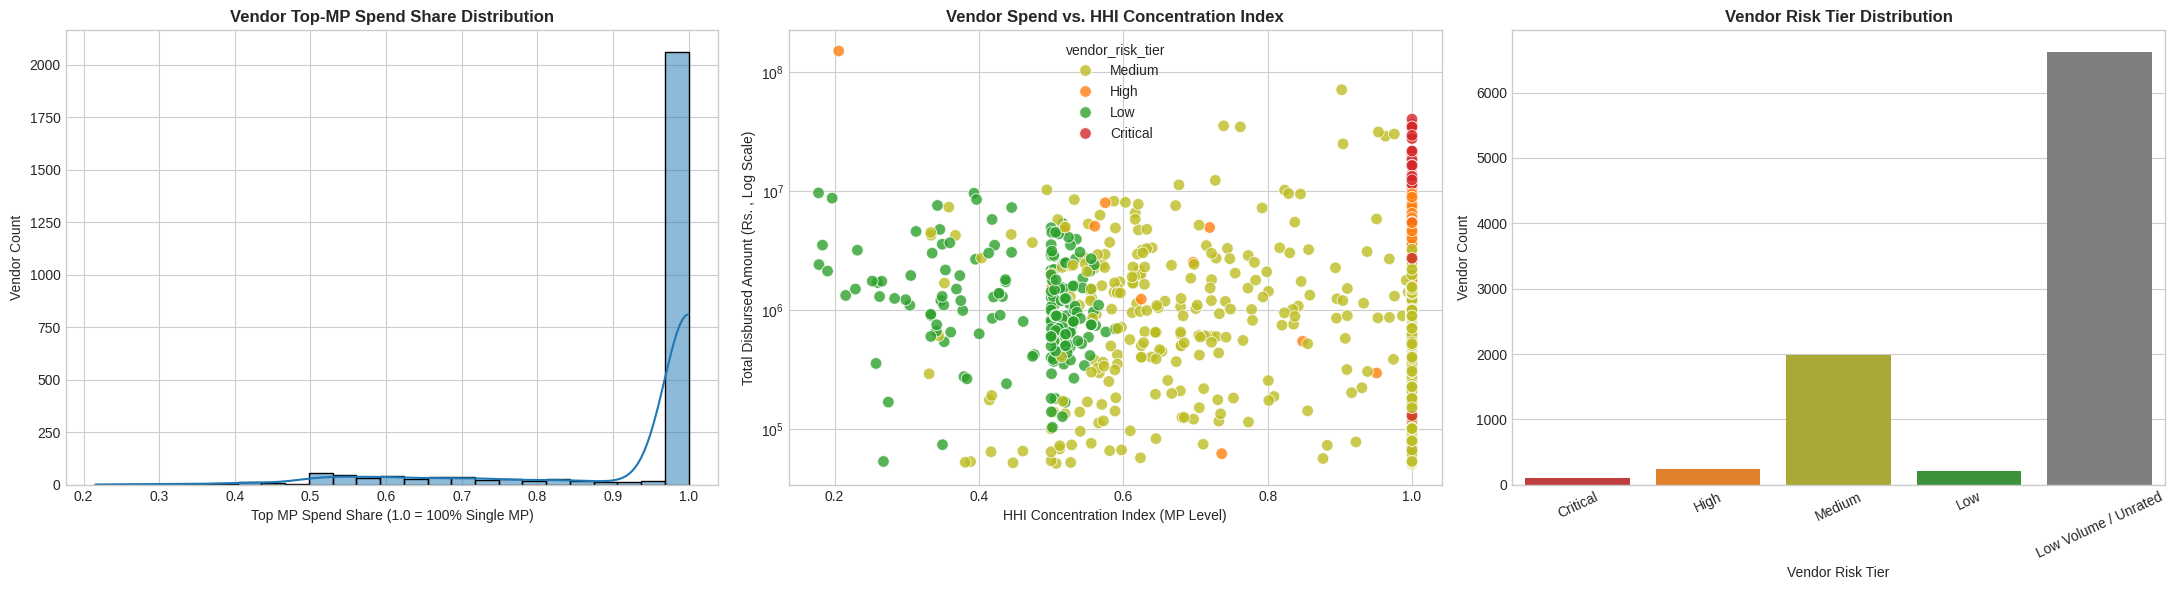

In [9]:
#  Visualizations for Dashboard & ML Model Audit
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

active_vendors = vendor_df[vendor_df["is_active_vendor"]].copy()

# Plot 1: Distribution of Top MP Spend Share
sns.histplot(
    data=active_vendors,
    x="top_mp_spend_share",
    bins=25,
    kde=True,
    ax=axes[0],
    color="#1f77b4"
)
axes[0].set_title("Vendor Top-MP Spend Share Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Top MP Spend Share (1.0 = 100% Single MP)")
axes[0].set_ylabel("Vendor Count")

# Plot 2: Total Spend vs HHI Concentration Scatter Plot
sns.scatterplot(
    data=active_vendors,
    x="hhi_within_mp",
    y="total_disbursed",
    hue="vendor_risk_tier",
    palette={"Critical": "#d62728", "High": "#ff7f0e", "Medium": "#bcbd22", "Low": "#2ca02c"},
    alpha=0.8,
    s=70,
    ax=axes[1]
)
axes[1].set_yscale("log")
axes[1].set_title("Vendor Spend vs. HHI Concentration Index", fontsize=12, fontweight="bold")
axes[1].set_xlabel("HHI Concentration Index (MP Level)")
axes[1].set_ylabel("Total Disbursed Amount (Rs. , Log Scale)")

# Plot 3: Vendor Risk Tier Counts
tier_order = ["Critical", "High", "Medium", "Low", "Low Volume / Unrated"]
tier_counts = vendor_df["vendor_risk_tier"].value_counts().reindex(tier_order).fillna(0)

sns.barplot(
    x=tier_counts.index,
    y=tier_counts.values,
    ax=axes[2],
    palette=["#d62728", "#ff7f0e", "#bcbd22", "#2ca02c", "#7f7f7f"]
)
axes[2].set_title("Vendor Risk Tier Distribution", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Vendor Risk Tier")
axes[2].set_ylabel("Vendor Count")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()

# Save Visualization Figure
plot_path = OUTPUT_DIR / "feature5_vendor_concentration_distribution.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
logger.info("Saved visualization plot to %s", plot_path)



In [10]:
# Artifact Export & Data Bus Update (Work-Vendor Bridge & Work Aggregates)
import json
from datetime import datetime, timezone

# 1. Export Full Vendor Master Risk Table
v_csv_path = OUTPUT_DIR / "feature5_vendor_risk.csv"
v_parquet_path = OUTPUT_DIR / "feature5_vendor_risk.parquet"

vendor_df.to_csv(v_csv_path, index=False)
vendor_df.to_parquet(v_parquet_path, index=False)
logger.info("Exported vendor master risk table: %s & %s", v_csv_path, v_parquet_path)

# 2. Build and Export Work-Vendor Bridge Artifact: grain (work_key, vendor_id)
exp_work_vendor = exp_clean.groupby(["work_key", "vendor_id"]).agg(
    vendor_spend=("fund_disbursed_amount", "sum"),
    vendor_tranche_count=("fund_disbursed_amount", "count")
).reset_index()

work_tot_spend = exp_work_vendor.groupby("work_key")["vendor_spend"].sum().rename("work_total_expenditure")
exp_work_vendor = exp_work_vendor.merge(work_tot_spend, on="work_key")
exp_work_vendor["vendor_spend_share_of_work"] = exp_work_vendor["vendor_spend"] / np.maximum(1.0, exp_work_vendor["work_total_expenditure"])
exp_work_vendor = exp_work_vendor.merge(vendor_df[["vendor_id", "vendor_risk_score", "vendor_risk_tier"]], on="vendor_id", how="left")

# Do not replace null vendor risk with zero in the bridge
exp_work_vendor["known_vendor_spend"] = np.where(exp_work_vendor["vendor_risk_score"].notna(), exp_work_vendor["vendor_spend"], 0.0)
exp_work_vendor["unknown_vendor_spend"] = np.where(exp_work_vendor["vendor_risk_score"].isna(), exp_work_vendor["vendor_spend"], 0.0)
exp_work_vendor["spend_x_risk"] = np.where(exp_work_vendor["vendor_risk_score"].notna(), exp_work_vendor["vendor_spend"] * exp_work_vendor["vendor_risk_score"], 0.0)

bridge_csv_path = SHARED_ARTIFACT_DIR / "fact_work_vendor.csv"
bridge_parquet_path = SHARED_ARTIFACT_DIR / "fact_work_vendor.parquet"
exp_work_vendor.to_csv(bridge_csv_path, index=False)
exp_work_vendor.to_parquet(bridge_parquet_path, index=False)
logger.info("Exported normalized work-vendor bridge artifact (%d rows) to %s", len(exp_work_vendor), bridge_parquet_path)

# 3. Work-Level Aggregates for fact_work_feature5
wv_agg = exp_work_vendor.groupby("work_key").agg(
    work_vendor_count=("vendor_id", "count"),
    work_known_vendor_spend=("known_vendor_spend", "sum"),
    work_unknown_vendor_spend=("unknown_vendor_spend", "sum"),
    total_work_spend=("vendor_spend", "sum"),
    work_max_vendor_risk_score=("vendor_risk_score", "max"),
    valid_spend_weighted_num=("spend_x_risk", "sum")
).reset_index()

wv_agg["work_unknown_vendor_spend_share"] = wv_agg["work_unknown_vendor_spend"] / np.maximum(1.0, wv_agg["total_work_spend"])
wv_agg["work_vendor_risk_coverage"] = wv_agg["work_known_vendor_spend"] / np.maximum(1.0, wv_agg["total_work_spend"])
wv_agg["work_spend_weighted_vendor_risk"] = np.where(wv_agg["work_known_vendor_spend"] > 0, wv_agg["valid_spend_weighted_num"] / wv_agg["work_known_vendor_spend"], np.nan)

wv_top = exp_work_vendor.sort_values(by=["work_key", "vendor_spend"], ascending=[True, False]).drop_duplicates(subset=["work_key"])
wv_top_sub = wv_top[["work_key", "vendor_id", "vendor_spend_share_of_work", "vendor_risk_score"]].rename(
    columns={"vendor_id": "work_top_vendor_id", "vendor_spend_share_of_work": "work_top_vendor_spend_share", "vendor_risk_score": "work_top_vendor_risk_score"}
)

wv_work_summary = wv_agg.merge(wv_top_sub, on="work_key", how="left")
fact_work_feature5 = fact_work.merge(wv_work_summary, on="work_key", how="left")

bus_parquet_path = SHARED_ARTIFACT_DIR / "fact_work_feature5.parquet"
bus_csv_path = SHARED_ARTIFACT_DIR / "fact_work_feature5.csv"

fact_work_feature5.to_parquet(bus_parquet_path, index=False)
fact_work_feature5.to_csv(bus_csv_path, index=False)

fact_work_feature5.to_parquet(OUTPUT_DIR / "feature5_fact_work_vendor_risk.parquet", index=False)
fact_work_feature5.to_csv(OUTPUT_DIR / "feature5_fact_work_vendor_risk.csv", index=False)

logger.info("Successfully updated shared data bus artifact: %s (Shape: %s)", bus_parquet_path, fact_work_feature5.shape)
metadata = {
    "feature": "Feature 5 - Vendor Concentration Risk",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "total_vendors_processed": int(len(vendor_df)),
    "active_vendors_processed": int(vendor_df["is_active_vendor"].sum()),
    "bridge_rows": int(len(exp_work_vendor)),
    "multi_vendor_work_count": int((exp_work_vendor.groupby("work_key")["vendor_id"].nunique() > 1).sum()),
    "total_known_vendor_spend": float(exp_work_vendor["known_vendor_spend"].sum()),
    "total_unknown_vendor_spend": float(exp_work_vendor["unknown_vendor_spend"].sum()),
    "vendor_risk_coverage": float(exp_work_vendor["known_vendor_spend"].sum() / max(1.0, exp_work_vendor["vendor_spend"].sum())),
    "artifacts": {
        "vendor_risk_csv": str(v_csv_path),
        "vendor_risk_parquet": str(v_parquet_path),
        "bridge_csv": str(bridge_csv_path),
        "bridge_parquet": str(bridge_parquet_path),
        "work_fact_csv": str(bus_csv_path),
        "work_fact_parquet": str(bus_parquet_path)
    }
}
with open(OUTPUT_DIR / "feature5_run_metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2, default=str)


